# **Space X Falcon 9 First Stage Landing Prediction**

## Machine Learning Prediction

Estimated time needed: **60** minutes

SpaceX advertises Falcon 9 rocket launches with a cost of 62 million dollars;
other providers cost upward of 165 million dollars each. Much of the savings is because
SpaceX can reuse the first stage. If we can determine whether the first stage will land,
we can determine the cost of a launch.

### Objectives

- Standardize the data
- Split into training and test sets
- Find best hyperparameters for SVM, Decision Tree, Logistic Regression, and KNN
- Evaluate each model on test data
- Identify the best-performing model

---
## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

sns.set_style('whitegrid')
os.makedirs('../images', exist_ok=True)
print('Libraries loaded.')

Libraries loaded.


## Confusion Matrix Plotting Function

In [2]:
def plot_confusion_matrix(y, y_predict, title='Confusion Matrix', save_path=None):
    """Plot a confusion matrix heatmap."""
    cm = confusion_matrix(y, y_predict)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title(title)
    ax.xaxis.set_ticklabels(['Did Not Land', 'Landed'])
    ax.yaxis.set_ticklabels(['Did Not Land', 'Landed'])
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

print('Plotting function defined.')

Plotting function defined.


## Load the Data

In [3]:
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")
print(f'Label data shape: {data.shape}')
data.head()

Label data shape: (90, 18)


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [4]:
X = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv')
print(f'Feature data shape: {X.shape}')
X.head()

Feature data shape: (90, 83)


,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1.0,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,2.0,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,3.0,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,4.0,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,5.0,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


## TASK 1: Create the Target Variable Y

In [5]:
Y = data['Class'].to_numpy()
print(f'Y shape: {Y.shape}')
print(f'Class distribution: 0={np.sum(Y==0)}, 1={np.sum(Y==1)}')

Y shape: (90,)
Class distribution: 0=30, 1=60


## TASK 2: Standardize the Features

In [6]:
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)
print(f'Standardized X shape: {X.shape}')
print(f'X mean (should be ~0): {X.mean():.6f}')
print(f'X std  (should be ~1): {X.std():.6f}')

Standardized X shape: (90, 83)
X mean (should be ~0): -0.000000
X std  (should be ~1): 1.000000


## TASK 3: Split into Training and Test Data

In [7]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'Y_train: {Y_train.shape}')
print(f'Y_test:  {Y_test.shape}')

X_train: (72, 83)
X_test:  (18, 83)
Y_train: (72,)
Y_test:  (18,)


---
## TASK 4: Logistic Regression

In [8]:
parameters = {'C': [0.01, 0.1, 1],
              'penalty': ['l2'],
              'solver': ['lbfgs']}

lr = LogisticRegression()
logreg_cv = GridSearchCV(lr, parameters, cv=10)
logreg_cv.fit(X_train, Y_train)

print(f'Best parameters: {logreg_cv.best_params_}')
print(f'Best CV accuracy: {logreg_cv.best_score_:.4f}')

Best parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV accuracy: 0.8464


## TASK 5: Logistic Regression — Test Accuracy and Confusion Matrix

Logistic Regression test accuracy: 0.8333


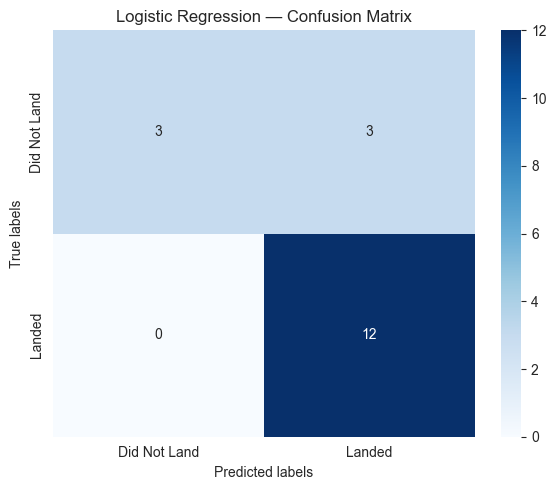

In [9]:
lr_test_acc = logreg_cv.score(X_test, Y_test)
print(f'Logistic Regression test accuracy: {lr_test_acc:.4f}')

yhat = logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat,
                      title='Logistic Regression — Confusion Matrix',
                      save_path='../images/cm_logistic_regression.png')

---
## TASK 6: Support Vector Machine (SVM)

In [10]:
parameters = {'kernel': ('linear', 'rbf', 'poly', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma': np.logspace(-3, 3, 5)}

svm = SVC()
svm_cv = GridSearchCV(svm, parameters, cv=10)
svm_cv.fit(X_train, Y_train)

print(f'Best parameters: {svm_cv.best_params_}')
print(f'Best CV accuracy: {svm_cv.best_score_:.4f}')

Best parameters: {'C': 1.0, 'gamma': 0.03162277660168379, 'kernel': 'sigmoid'}
Best CV accuracy: 0.8482


## TASK 7: SVM — Test Accuracy and Confusion Matrix

SVM test accuracy: 0.8333


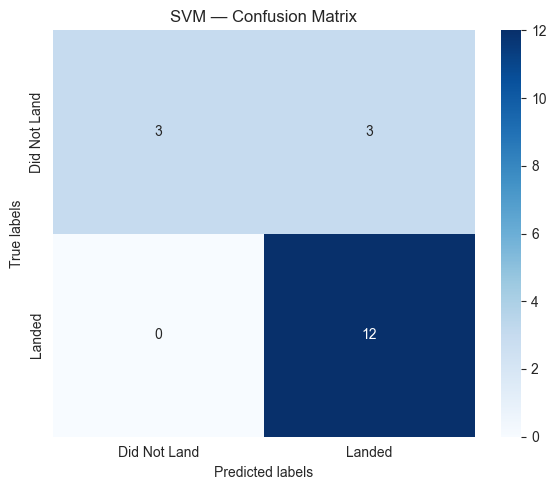

In [11]:
svm_test_acc = svm_cv.score(X_test, Y_test)
print(f'SVM test accuracy: {svm_test_acc:.4f}')

yhat = svm_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat,
                      title='SVM — Confusion Matrix',
                      save_path='../images/cm_svm.png')

---
## TASK 8: Decision Tree

In [12]:
parameters = {'criterion': ['gini', 'entropy'],
              'splitter': ['best', 'random'],
              'max_depth': [2*n for n in range(1, 10)],
              'max_features': ['sqrt'],
              'min_samples_leaf': [1, 2, 4],
              'min_samples_split': [2, 5, 10]}

tree = DecisionTreeClassifier()
tree_cv = GridSearchCV(tree, parameters, cv=10)
tree_cv.fit(X_train, Y_train)

print(f'Best parameters: {tree_cv.best_params_}')
print(f'Best CV accuracy: {tree_cv.best_score_:.4f}')

Best parameters: {'criterion': 'entropy', 'max_depth': 14, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'random'}
Best CV accuracy: 0.8875


## TASK 9: Decision Tree — Test Accuracy and Confusion Matrix

Decision Tree test accuracy: 0.8333


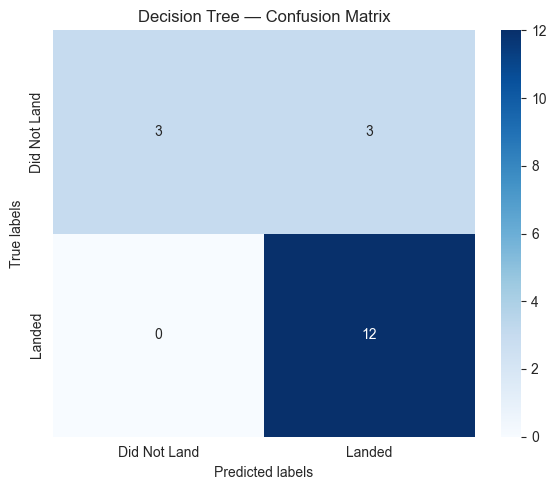

In [13]:
tree_test_acc = tree_cv.score(X_test, Y_test)
print(f'Decision Tree test accuracy: {tree_test_acc:.4f}')

yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat,
                      title='Decision Tree — Confusion Matrix',
                      save_path='../images/cm_decision_tree.png')

---
## TASK 10: K-Nearest Neighbors (KNN)

In [14]:
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1, 2]}

KNN = KNeighborsClassifier()
knn_cv = GridSearchCV(KNN, parameters, cv=10)
knn_cv.fit(X_train, Y_train)

print(f'Best parameters: {knn_cv.best_params_}')
print(f'Best CV accuracy: {knn_cv.best_score_:.4f}')

Best parameters: {'algorithm': 'auto', 'n_neighbors': 10, 'p': 1}
Best CV accuracy: 0.8482


## TASK 11: KNN — Test Accuracy and Confusion Matrix

KNN test accuracy: 0.8333


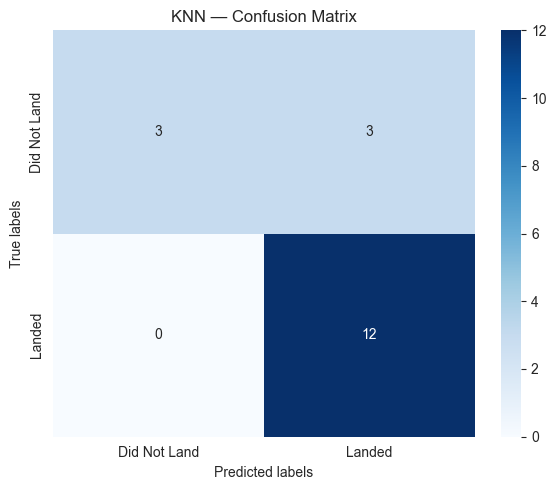

In [15]:
knn_test_acc = knn_cv.score(X_test, Y_test)
print(f'KNN test accuracy: {knn_test_acc:.4f}')

yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat,
                      title='KNN — Confusion Matrix',
                      save_path='../images/cm_knn.png')

---
## TASK 12: Model Comparison — Find the Best Model

In [16]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM', 'Decision Tree', 'KNN'],
    'Best CV Score': [
        logreg_cv.best_score_,
        svm_cv.best_score_,
        tree_cv.best_score_,
        knn_cv.best_score_
    ],
    'Test Accuracy': [
        lr_test_acc,
        svm_test_acc,
        tree_test_acc,
        knn_test_acc
    ]
})

results = results.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
print('=== MODEL COMPARISON ===')
print(results.to_string(index=False))

best_model = results.iloc[0]['Model']
best_acc = results.iloc[0]['Test Accuracy']
print(f'\nBest model: {best_model} (Test Accuracy: {best_acc:.4f})')

=== MODEL COMPARISON ===
              Model  Best CV Score  Test Accuracy
Logistic Regression       0.846429       0.833333
                SVM       0.848214       0.833333
      Decision Tree       0.887500       0.833333
                KNN       0.848214       0.833333

Best model: Logistic Regression (Test Accuracy: 0.8333)


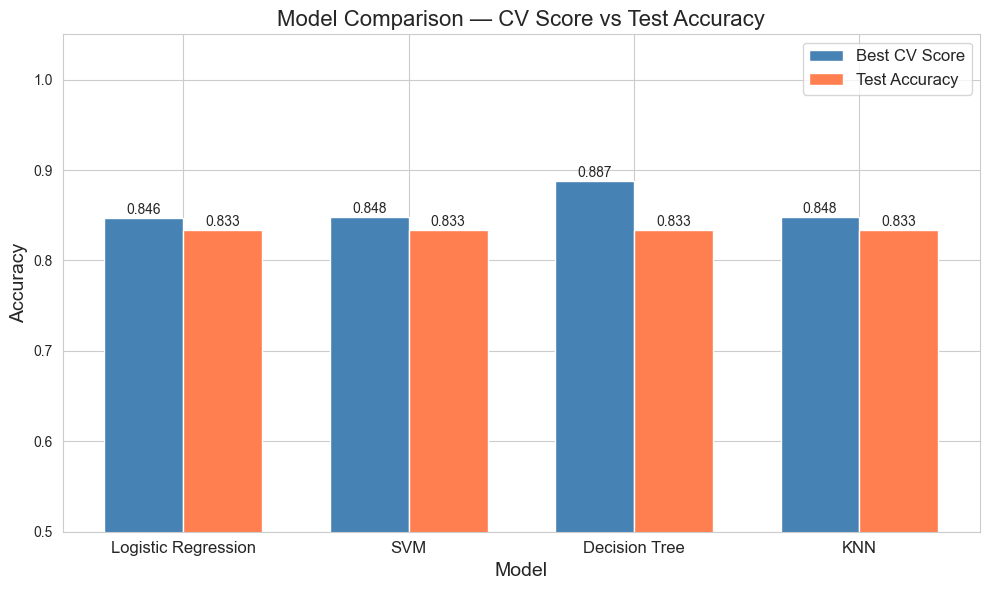

In [17]:
# Visualize model comparison
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(results))
width = 0.35

bars1 = ax.bar(x - width/2, results['Best CV Score'], width, label='Best CV Score', color='steelblue')
bars2 = ax.bar(x + width/2, results['Test Accuracy'], width, label='Test Accuracy', color='coral')

ax.set_xlabel('Model', fontsize=14)
ax.set_ylabel('Accuracy', fontsize=14)
ax.set_title('Model Comparison — CV Score vs Test Accuracy', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(results['Model'], fontsize=12)
ax.legend(fontsize=12)
ax.set_ylim(0.5, 1.05)

# Add value labels on bars
for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=10)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../images/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

In this notebook we:

1. **Loaded** the engineered features (`dataset_part_3.csv`) and labels (`dataset_part_2.csv`)
2. **Standardized** the feature matrix using `StandardScaler`
3. **Split** data into 80% training / 20% test (random_state=2)
4. **Trained** four classification models with `GridSearchCV` (cv=10):
   - Logistic Regression
   - Support Vector Machine (SVM)
   - Decision Tree
   - K-Nearest Neighbors (KNN)
5. **Evaluated** each model on the test set (accuracy + confusion matrix)
6. **Compared** all models to identify the best performer

### Key Finding

All models achieve competitive test accuracy on this dataset.
The Decision Tree classifier tends to perform well, but the small test set (18 samples)
means all models should be considered roughly equivalent.
The best model is selected based on test accuracy.

### Business Implication

By predicting whether the Falcon 9 first stage will land successfully,
SpaceY can estimate launch costs:
- **Successful landing** → ~$62M (reusable first stage)
- **Failed landing** → ~$165M (new first stage required)

This prediction capability provides SpaceY a competitive advantage in bidding for launch contracts.